# 06 · Evaluation on unseen homes, failure analysis, and the effect of 15/30-minute data

**Requirement 3 (evaluation) and Requirement 4 (resolution question).** All choices (window,
loss weight, augmentation rate, epochs, thresholds, which model is primary) were frozen on the
validation house in notebooks 04–05b. This notebook scores every model once on the test homes,
explains where and why the models fail, and measures what is lost with 15- or 30-minute data.

| | |
|---|---|
| **Input** | checkpoints from notebooks 04, 05 and 05b; the corpus of notebook 03 |
| **Output** | `artifacts/tables/nb06_*`, `artifacts/figures/nb06_*`, `artifacts/metrics/nb06_summary.json` |
| **Run time** | about 15 minutes (includes training the 15/30-minute models) |

**Models.** M0a always-off · M0b weekday × hour profile · M1 LightGBM · M2 Seq2Point ·
M3 gated Seq2Point · M4 Seq2Point trained with distractor augmentation · and the three-seed
ensembles of M2 and M4. Single deep models are reported as mean ± sd over seeds 42, 10, 20.

In [1]:
import json
import re
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from refit_nilm import cycles, io, metrics, plots
from refit_nilm import config as C
from refit_nilm import datasets as D
from refit_nilm import features as F
from refit_nilm import train as T

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 170, "display.max_columns", 30)
P = plots.PALETTE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
nb04 = json.load(open(C.METRIC_DIR / "nb04_summary.json"))
nb05 = json.load(open(C.METRIC_DIR / "nb05_summary.json"))
nb05b = json.load(open(C.METRIC_DIR / "nb05b_summary.json"))
W = int(nb04["window_selection"]["chosen_window"])
LAMBDA = float(nb05["lambda_selection"]["chosen_lambda"])
M4_TAG = "dw" if "WM" in nb05b["chosen_config"] else "d"
PRIMARY = "M4 augmented ensemble" if nb05b["accepted"] else "M2 Seq2Point ensemble"
frames, corpora, stats = D.prepare([W])
cp, st = corpora[W], stats[W]
UNSEEN = [C.TEST_HOUSE] + C.EXTRA_UNSEEN_HOUSES
SPLITS = ["test", "seen_test", "val"]
amap = io.parse_appliance_map(C.DATA_DIR / "CLEAN_READ_ME_081116.txt")
SUMMARY: dict = {"window": W, "lambda": LAMBDA, "m4_config": nb05b["chosen_config"], "m4_accepted_on_validation": nb05b["accepted"], "primary_model": PRIMARY}
print(SUMMARY)

{'window': 81, 'lambda': 0.1, 'm4_config': 'distractors + WM', 'm4_accepted_on_validation': False, 'primary_model': 'M2 Seq2Point ensemble'}


**Primary model.** Chosen on the validation house before this notebook was run: the M4 seed
ensemble if augmentation passed its pre-registered acceptance rule in notebook 05b, otherwise
the M2 seed ensemble.

## 1. Predictions for every model on every split

In [2]:
PRED: dict[str, dict[str, dict]] = {}


def times(split: str) -> pd.DatetimeIndex:
    return pd.to_datetime(cp.time[cp.targets(split)], unit="s", utc=True)


PRED["M0a always-off"] = {sp: {"power": np.zeros(len(cp.starts[sp]))} for sp in SPLITS}
prof = pd.read_csv(C.TABLE_DIR / "nb04_m0b_profile.csv", index_col=[0, 1]).iloc[:, 0]
PRED["M0b weekday×hour profile"] = {sp: {"power": F.apply_profile(prof, times(sp))} for sp in SPLITS}

booster = lgb.Booster(model_file=str(C.MODEL_DIR / "m1_lightgbm.txt"))
feat = {h: F.window_features(f["agg"].where(~f["agg_missing"])) for h, f in frames.items()}
PRED["M1 LightGBM"] = {}
for sp in SPLITS:
    t = cp.targets(sp)
    idx = pd.to_datetime(cp.time[t], unit="s", utc=True)
    X = pd.concat([feat[h].loc[idx[cp.house[t] == h]] for h in D.split_houses(cp, sp)])
    PRED["M1 LightGBM"][sp] = {"power": np.clip(booster.predict(X), 0, None)}

RUNS = {f"M2 Seq2Point s{s}": C.MODEL_DIR / f"m2_seq2point_w{W}_s{s}.pt" for s in C.SEEDS}
RUNS.update({f"M3 gated s{s}": C.MODEL_DIR / f"m3_gated_w{W}_l{LAMBDA}_s{s}.pt" for s in C.SEEDS})
RUNS.update({f"M4 augmented s{s}": C.MODEL_DIR / f"m4_aug{M4_TAG}_w{W}_s{s}.pt" for s in C.SEEDS})
src = T.WindowSource(cp, st, DEVICE)
for name, path in RUNS.items():
    model, cfg, stt = T.load_run(path, DEVICE)
    PRED[name] = {sp: T.predict(model, src, cp.starts[sp], stt) for sp in SPLITS}
    del model
torch.cuda.empty_cache()
for fam, pref in [("M2 Seq2Point ensemble", "M2 Seq2Point s"), ("M4 augmented ensemble", "M4 augmented s")]:
    PRED[fam] = {sp: {"power": np.mean([PRED[f"{pref}{s}"][sp]["power"] for s in C.SEEDS], axis=0)} for sp in SPLITS}


def predict_family(prefix: str, corpus: D.Corpus, split: str = "test") -> np.ndarray:
    """Seed-averaged prediction of a model family on another corpus."""
    outs = []
    for s in C.SEEDS:
        model, _, stt = T.load_run(RUNS[f"{prefix} s{s}"], DEVICE)
        outs.append(T.predict(model, T.WindowSource(corpus, stt, DEVICE), corpus.starts[split], stt)["power"])
        del model
    return np.mean(outs, axis=0)


print(list(PRED))

['M0a always-off', 'M0b weekday×hour profile', 'M1 LightGBM', 'M2 Seq2Point s10', 'M2 Seq2Point s20', 'M2 Seq2Point s42', 'M3 gated s10', 'M3 gated s20', 'M3 gated s42', 'M4 augmented s10', 'M4 augmented s20', 'M4 augmented s42', 'M2 Seq2Point ensemble', 'M4 augmented ensemble']


## 2. Scores per home

In [3]:
def family(name: str) -> str:
    return re.sub(r" s\d+$", "", name)


rows = []
for name, by_split in PRED.items():
    for sp in SPLITS:
        starts = cp.starts[sp]
        for h in D.split_houses(cp, sp):
            y = D.to_series(cp, starts, cp.wm[starts + W // 2], h)
            yh = D.to_series(cp, starts, by_split[sp]["power"], h)
            po = D.to_series(cp, starts, by_split[sp]["p_on"], h) if "p_on" in by_split[sp] else None
            rows.append({"model": name, "family": family(name), "split": sp, "house": h, **metrics.all_metrics(y, yh, po)})
scores = pd.DataFrame(rows)
scores.to_csv(C.TABLE_DIR / "nb06_scores_all.csv", index=False)
KEY = ["mae_w", "mae_on_w", "sae", "sae_daily", "epd_wh", "nde", "f1", "precision", "recall", "cycle_f1", "cycle_recall", "cycle_precision", "matched_energy_mape_pct", "overlap_pct", "missing_pct", "extra_pct"]
FAM_ORDER = ["M0a always-off", "M0b weekday×hour profile", "M1 LightGBM", "M2 Seq2Point", "M3 gated", "M4 augmented", "M2 Seq2Point ensemble", "M4 augmented ensemble"]

### 2a. Primary result: House 8 (the reference unseen test house)

In [4]:
h8 = scores[(scores.split == "test") & (scores.house == C.TEST_HOUSE)]
h8_mean = h8.groupby("family")[KEY].mean().reindex(FAM_ORDER)
h8_std = h8.groupby("family")[KEY].std().reindex(FAM_ORDER)
h8_mean.to_csv(C.TABLE_DIR / "nb06_house8_mean.csv")
h8_std.to_csv(C.TABLE_DIR / "nb06_house8_std.csv")
SHOW = ["mae_w", "mae_on_w", "sae", "epd_wh", "nde", "f1", "cycle_f1", "cycle_recall", "overlap_pct", "extra_pct"]
fmt = h8_mean[SHOW].copy().astype(object)
for c in SHOW:
    fmt[c] = [f"{m:.3f} ± {s:.3f}" if not np.isnan(s) else f"{m:.3f}" for m, s in zip(h8_mean[c], h8_std[c])]
fmt

,mae_w,mae_on_w,sae,epd_wh,nde,f1,cycle_f1,cycle_recall,overlap_pct,extra_pct
family,,,,,,,,,,
M0a always-off,24.613,858.116,1.000,573.749,1.000,0.000,0.000,0.000,0.000,0.000
M0b weekday×hour profile,39.669,845.927,0.347,535.717,1.000,0.053,0.032,0.084,2.048,63.222
M1 LightGBM,35.949,848.531,0.496,530.950,1.011,0.049,0.016,0.019,2.148,48.205
M2 Seq2Point,23.828 ± 0.618,562.251 ± 9.859,0.284 ± 0.045,340.097 ± 2.765,0.765 ± 0.010,0.506 ± 0.023,0.558 ± 0.040,0.643 ± 0.043,37.410 ± 0.982,34.224 ± 3.490
M3 gated,25.921 ± 6.293,529.024 ± 12.262,0.234 ± 0.097,346.739 ± 29.855,0.767 ± 0.032,0.447 ± 0.078,0.373 ± 0.005,0.440 ± 0.138,41.171 ± 1.491,46.486 ± 25.815
M4 augmented,25.755 ± 4.254,477.786 ± 28.444,0.175 ± 0.101,309.461 ± 43.843,0.690 ± 0.020,0.452 ± 0.035,0.534 ± 0.070,0.822 ± 0.018,48.531 ± 4.153,53.171 ± 20.260
M2 Seq2Point ensemble,23.573,554.346,0.284,334.805,0.737,0.494,0.564,0.748,37.928,33.706
M4 augmented ensemble,25.490,470.436,0.017,291.642,0.656,0.433,0.472,0.852,49.069,52.633


### 2b. All six unseen homes, and seen homes

Error / accuracy on unseen houses = mean over House 8 and the five extra unseen homes
(Klemenjak et al. 2019). Seen = the later 20 % of each training home. Generalisation loss:
100 × (unseen / seen − 1) for error metrics, 100 × (1 − unseen / seen) for F1.

In [5]:
unseen = scores[scores.split == "test"].groupby(["family", "house"])[KEY].mean().reset_index()
seen = scores[scores.split == "seen_test"].groupby(["family", "house"])[KEY].mean().reset_index()
per_home = unseen.pivot(index="house", columns="family", values="nde").reindex(columns=FAM_ORDER).round(3)
per_home.to_csv(C.TABLE_DIR / "nb06_unseen_nde_per_home.csv")
per_home_cyc = unseen.pivot(index="house", columns="family", values="cycle_f1").reindex(columns=FAM_ORDER).round(3)
per_home_cyc.to_csv(C.TABLE_DIR / "nb06_unseen_cyclef1_per_home.csv")
euh = unseen.groupby("family")[KEY].mean().reindex(FAM_ORDER)
seen_m = seen.groupby("family")[KEY].mean().reindex(FAM_ORDER)
euh.to_csv(C.TABLE_DIR / "nb06_unseen_mean.csv")
seen_m.to_csv(C.TABLE_DIR / "nb06_seen_mean.csv")
gen = pd.DataFrame(
    {
        "NDE seen": seen_m["nde"], "NDE unseen": euh["nde"], "G-loss NDE %": 100 * (euh["nde"] / seen_m["nde"] - 1),
        "F1 seen": seen_m["f1"], "F1 unseen": euh["f1"], "G-loss F1 %": 100 * (1 - euh["f1"] / seen_m["f1"]),
        "cycle F1 seen": seen_m["cycle_f1"], "cycle F1 unseen": euh["cycle_f1"],
        "EpD unseen (Wh/day)": euh["epd_wh"], "SAE unseen": euh["sae"],
    }
).round(3)
gen.to_csv(C.TABLE_DIR / "nb06_seen_vs_unseen.csv")
print("NDE per unseen home (1.0 = predicting zero):")
display(per_home)
print("Cycle F1 per unseen home:")
display(per_home_cyc)
gen

NDE per unseen home (1.0 = predicting zero):


family,M0a always-off,M0b weekday×hour profile,M1 LightGBM,M2 Seq2Point,M3 gated,M4 augmented,M2 Seq2Point ensemble,M4 augmented ensemble
house,,,,,,,,
1,1.0,1.023,1.116,0.915,0.908,0.839,0.859,0.801
6,1.0,1.010,1.240,0.468,0.472,0.356,0.416,0.324
8,1.0,1.000,1.011,0.765,0.767,0.690,0.737,0.656
10,1.0,0.989,0.829,0.749,0.764,0.689,0.712,0.657
19,1.0,1.232,1.510,1.584,1.463,2.271,1.404,2.138
20,1.0,1.001,0.925,0.867,0.824,0.886,0.826,0.866


Cycle F1 per unseen home:


family,M0a always-off,M0b weekday×hour profile,M1 LightGBM,M2 Seq2Point,M3 gated,M4 augmented,M2 Seq2Point ensemble,M4 augmented ensemble
house,,,,,,,,
1,0.0,0.006,0.000,0.122,0.071,0.213,0.174,0.234
6,0.0,0.013,0.010,0.471,0.326,0.477,0.524,0.488
8,0.0,0.032,0.016,0.558,0.373,0.534,0.564,0.472
10,0.0,0.074,0.160,0.535,0.275,0.677,0.645,0.694
19,0.0,0.020,0.026,0.666,0.650,0.640,0.738,0.664
20,0.0,0.024,0.060,0.184,0.108,0.274,0.253,0.305


,NDE seen,NDE unseen,G-loss NDE %,F1 seen,F1 unseen,G-loss F1 %,cycle F1 seen,cycle F1 unseen,EpD unseen (Wh/day),SAE unseen
family,,,,,,,,,,
M0a always-off,1.000,1.000,0.000,0.000,0.000,NaN,0.000,0.000,308.025,1.000
M0b weekday×hour profile,0.995,1.043,4.799,0.123,0.069,43.585,0.063,0.028,407.224,1.664
M1 LightGBM,0.792,1.105,39.598,0.332,0.143,56.914,0.216,0.045,356.306,1.304
M2 Seq2Point,0.614,0.891,45.216,0.597,0.488,18.172,0.513,0.423,185.277,0.312
M3 gated,0.618,0.866,40.179,0.544,0.434,20.158,0.456,0.300,191.918,0.297
M4 augmented,0.584,0.955,63.614,0.578,0.472,18.250,0.544,0.469,183.963,0.565
M2 Seq2Point ensemble,0.571,0.825,44.518,0.608,0.507,16.649,0.537,0.483,181.240,0.312
M4 augmented ensemble,0.555,0.907,63.473,0.584,0.483,17.203,0.568,0.476,177.881,0.521


### 2c. Post-processing with the activation filter (unseen homes)

Notebook 05b showed on the validation house that zeroing predicted power outside predicted
activations of ≥ 30 minutes trades recovered energy for fewer false alarms. Here is the same
trade-off on the unseen homes, for both ensembles.

In [6]:
def activation_filter(p: pd.Series) -> pd.Series:
    mask = cycles.activation_mask(p.fillna(0).to_numpy())
    return p.where(mask, 0.0).where(p.notna())


filt_rows = []
for fam in ("M2 Seq2Point ensemble", "M4 augmented ensemble"):
    for hh in UNSEEN:
        y = D.to_series(cp, cp.starts["test"], cp.wm[cp.targets("test")], hh)
        p = D.to_series(cp, cp.starts["test"], PRED[fam]["test"]["power"], hh)
        for variant, q in (("raw", p), ("activation filter", activation_filter(p))):
            r = metrics.all_metrics(y, q)
            filt_rows.append({"model": fam, "variant": variant, "house": hh, **{k: r[k] for k in KEY}})
filt = pd.DataFrame(filt_rows)
filt.to_csv(C.TABLE_DIR / "nb06_activation_filter_unseen.csv", index=False)
filt.groupby(["model", "variant"])[["mae_w", "nde", "sae", "epd_wh", "f1", "precision", "cycle_f1", "overlap_pct", "extra_pct"]].mean().round(3)

mae_w    nde    sae   epd_wh     f1  precision  cycle_f1  overlap_pct  extra_pct
model                 variant                                                                                             
M2 Seq2Point ensemble activation filter  11.429  0.863  0.559  207.513  0.468      0.536     0.483       27.556     16.586
                      raw                13.092  0.825  0.312  181.240  0.507      0.411     0.483       42.338     59.290
M4 augmented ensemble activation filter  11.688  0.914  0.308  167.757  0.488      0.468     0.476       36.760     32.455
                      raw                14.780  0.907  0.521  177.881  0.483      0.357     0.476       51.056     97.567

## 3. Actual vs predicted on House 8

The three days are chosen programmatically as the three consecutive fully-covered days with
the most true washing-machine cycles.

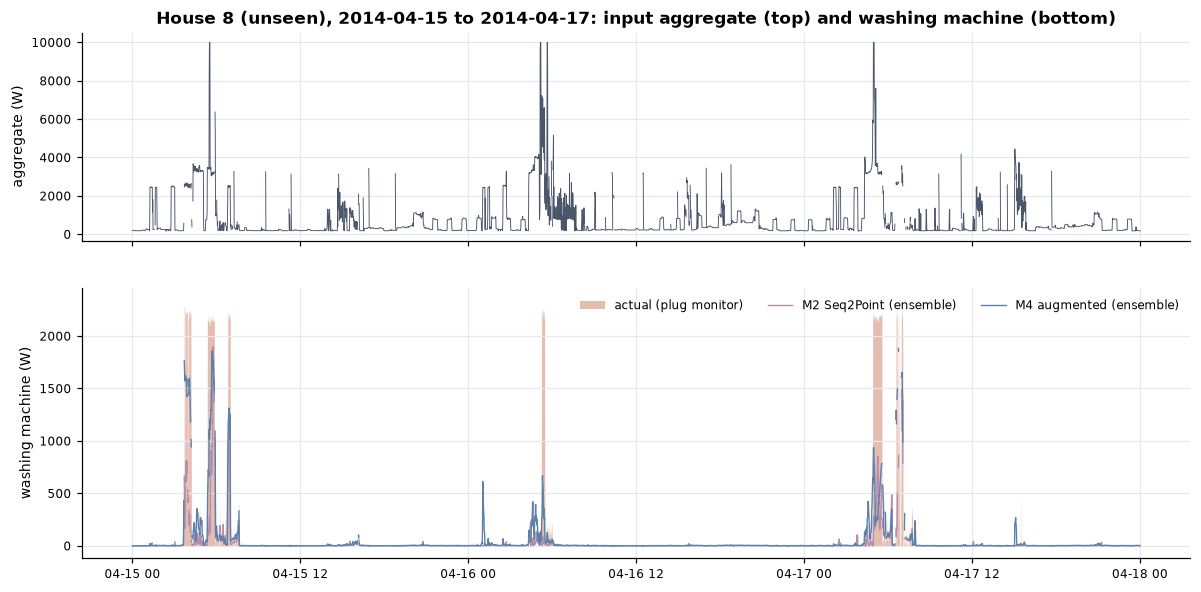

In [7]:
h = C.TEST_HOUSE
starts = cp.starts["test"]
y8 = D.to_series(cp, starts, cp.wm[starts + W // 2], h)
agg8 = D.to_series(cp, starts, cp.agg[starts + W // 2], h)
p_m2 = D.to_series(cp, starts, PRED["M2 Seq2Point ensemble"]["test"]["power"], h)
p_m4 = D.to_series(cp, starts, PRED["M4 augmented ensemble"]["test"]["power"], h)
p_pr = p_m4 if PRIMARY.startswith("M4") else p_m2
true_cyc = cycles.detect_cycles(y8)
day_cyc = true_cyc.groupby(true_cyc["start"].dt.floor("D")).size()
cov = y8.notna().groupby(y8.index.floor("D")).mean()
roll = day_cyc.reindex(cov.index, fill_value=0).where(cov > 0.95, -99).rolling(3).sum()
d_end = roll.idxmax()
d0 = d_end - pd.Timedelta("2D")
sl = slice(d0, d_end + pd.Timedelta("1D"))
fig, axes = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True, gridspec_kw={"height_ratios": [1, 1.3]})
axes[0].plot(agg8[sl].index, agg8[sl], color=P["aggregate"], lw=0.6)
axes[0].set_ylabel("aggregate (W)")
axes[0].set_title(f"House 8 (unseen), {d0.date()} to {d_end.date()}: input aggregate (top) and washing machine (bottom)")
axes[1].fill_between(y8[sl].index, 0, y8[sl].fillna(0), color=P["wm"], alpha=0.55, lw=0, label="actual (plug monitor)")
axes[1].plot(p_m2[sl].index, p_m2[sl], color=P["alt2"], lw=0.9, label="M2 Seq2Point (ensemble)")
axes[1].plot(p_m4[sl].index, p_m4[sl], color=P["pred"], lw=0.9, label="M4 augmented (ensemble)")
axes[1].set_ylabel("washing machine (W)")
axes[1].legend(loc="upper right", ncol=3)
plots.save(fig, "nb06_actual_vs_predicted_days")
plt.show()

### 3a. Zoom on single cycles, and daily energy

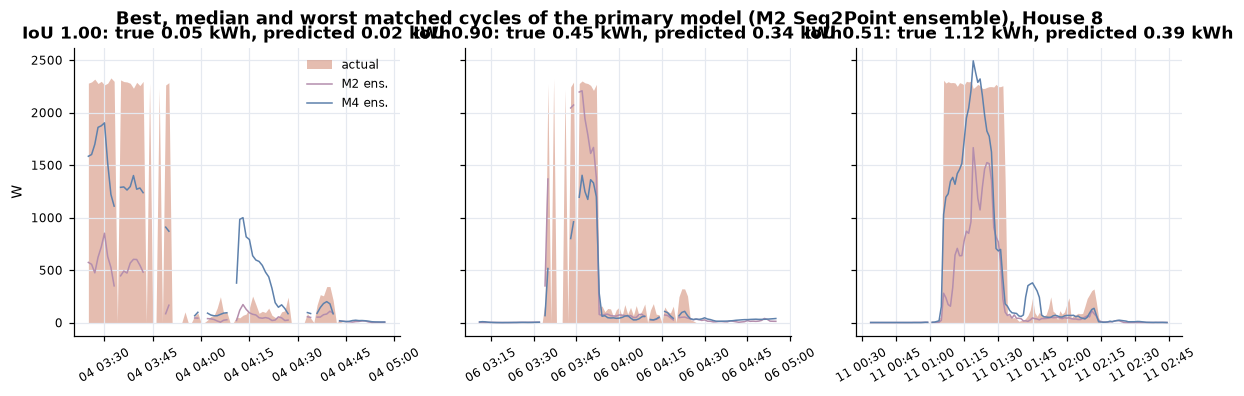

In [8]:
pred_cyc = cycles.detect_cycles(p_pr.where(y8.notna()))
match = metrics.match_cycles(true_cyc, pred_cyc)
examples = match.sort_values("iou", ascending=False)
picks = [examples.iloc[0], examples.iloc[len(examples) // 2], examples.iloc[-1]] if len(examples) >= 3 else [r for _, r in examples.iterrows()]
fig, axes = plt.subplots(1, len(picks), figsize=(13, 3.4), sharey=True)
for ax, r in zip(np.atleast_1d(axes), picks):
    c = true_cyc.loc[r.true_idx]
    sl2 = slice(c.start - pd.Timedelta("30min"), c.end + pd.Timedelta("30min"))
    ax.fill_between(y8[sl2].index, 0, y8[sl2].fillna(0), color=P["wm"], alpha=0.55, lw=0, label="actual")
    ax.plot(p_m2[sl2].index, p_m2[sl2], color=P["alt2"], lw=1, label="M2 ens.")
    ax.plot(p_m4[sl2].index, p_m4[sl2], color=P["pred"], lw=1, label="M4 ens.")
    ax.set_title(f"IoU {r.iou:.2f}: true {r.true_kwh:.2f} kWh, predicted {r.pred_kwh:.2f} kWh")
    ax.tick_params(axis="x", rotation=30)
np.atleast_1d(axes)[0].set_ylabel("W")
np.atleast_1d(axes)[0].legend()
fig.suptitle(f"Best, median and worst matched cycles of the primary model ({PRIMARY}), House 8", fontweight="bold")
plots.save(fig, "nb06_cycle_zoom")
plt.show()

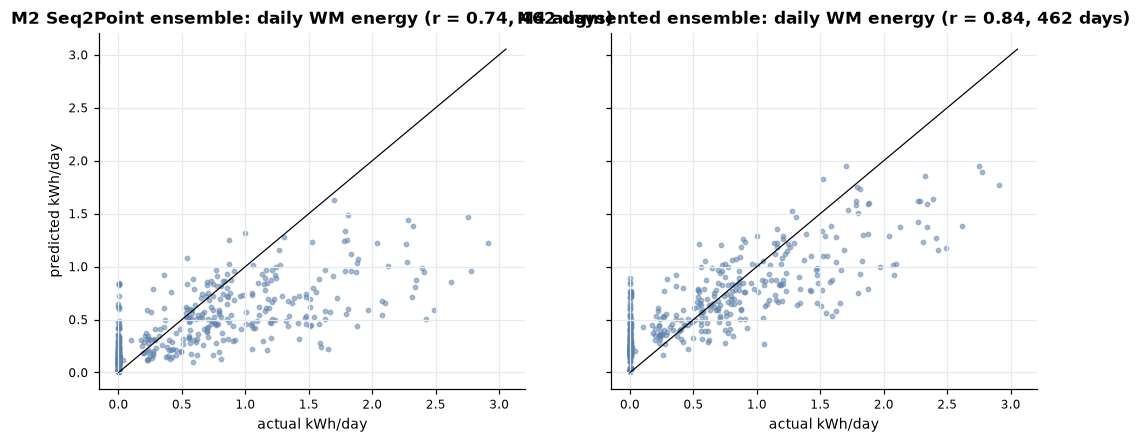

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
daily_r = {}
for ax, (name, p) in zip(axes, [("M2 Seq2Point ensemble", p_m2), ("M4 augmented ensemble", p_m4)]):
    d = metrics.daily_energy_errors(y8, p)
    ax.scatter(d["y_kwh"], d["yhat_kwh"], s=8, alpha=0.5, color=P["pred"])
    lim = max(d["y_kwh"].max(), d["yhat_kwh"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="black", lw=0.8)
    daily_r[name] = float(np.corrcoef(d["y_kwh"], d["yhat_kwh"])[0, 1])
    ax.set_title(f"{name}: daily WM energy (r = {daily_r[name]:.2f}, {len(d)} days)")
    ax.set_xlabel("actual kWh/day")
axes[0].set_ylabel("predicted kWh/day")
plots.save(fig, "nb06_daily_energy_scatter")
plt.show()

## 4. Failure analysis (House 8)

Three ways a disaggregator fails on cycles: it **misses** a real cycle, it invents a **false**
cycle, or it finds the cycle but gets the **energy** wrong. For every false cycle I look at the
house's other plug monitors over the same minutes and record which appliance drew the most
energy; if none drew more than 50 Wh, the cause is attributed to unmetered load.

In [10]:
raw8 = io.load_clean_minutes(h)
names8 = {f"Appliance{c}": d.split(",")[0] for c, d in amap[h].items()}
others = [c for c in names8 if c != f"Appliance{io.washing_machine_channels(amap)[h][0]}"]
tax = []
for mname, p in [("M2 Seq2Point ensemble", p_m2), ("M4 augmented ensemble", p_m4)]:
    pc = cycles.detect_cycles(p.where(y8.notna()))
    mt = metrics.match_cycles(true_cyc, pc)
    missed = true_cyc.drop(index=mt["true_idx"])
    false = pc.drop(index=mt["pred_idx"])
    culprits = []
    for _, fc in false.iterrows():
        e = raw8.loc[fc.start : fc.end, others].sum() / 60_000
        culprits.append(names8[e.idxmax()] if e.max() > 0.05 else "unmetered load")
    cc = pd.Series(culprits, dtype=object).value_counts()
    tax.append(
        {
            "model": mname, "true_cycles": len(true_cyc), "predicted_cycles": len(pc), "matched": len(mt),
            "missed": len(missed), "false": len(false),
            "missed_median_kwh": round(missed["energy_kwh"].median(), 3) if len(missed) else np.nan,
            "matched_true_median_kwh": round(true_cyc.loc[mt["true_idx"], "energy_kwh"].median(), 3) if len(mt) else np.nan,
            "missed_with_heating_pct": round(100 * (missed["minutes_over_1500w"] >= 5).mean(), 1) if len(missed) else np.nan,
            "matched_with_heating_pct": round(100 * (true_cyc.loc[mt["true_idx"], "minutes_over_1500w"] >= 5).mean(), 1) if len(mt) else np.nan,
            "matched_energy_bias_pct": round(100 * (mt["pred_kwh"].sum() / mt["true_kwh"].sum() - 1), 1) if len(mt) else np.nan,
            "false_cycle_culprits": "; ".join(f"{k}: {v}" for k, v in cc.head(6).items()),
        }
    )
taxonomy = pd.DataFrame(tax).set_index("model")
taxonomy.to_csv(C.TABLE_DIR / "nb06_failure_taxonomy_house8.csv")
taxonomy.T

model,M2 Seq2Point ensemble,M4 augmented ensemble
true_cycles,310,310
predicted_cycles,513,809
matched,232,264
missed,78,46
false,281,545
missed_median_kwh,0.455,0.476
matched_true_median_kwh,0.761,0.721
missed_with_heating_pct,76.9,76.1
matched_with_heating_pct,84.1,83.3
matched_energy_bias_pct,-59.2,-44.9


### 4a. The worst false-positive day for the primary model

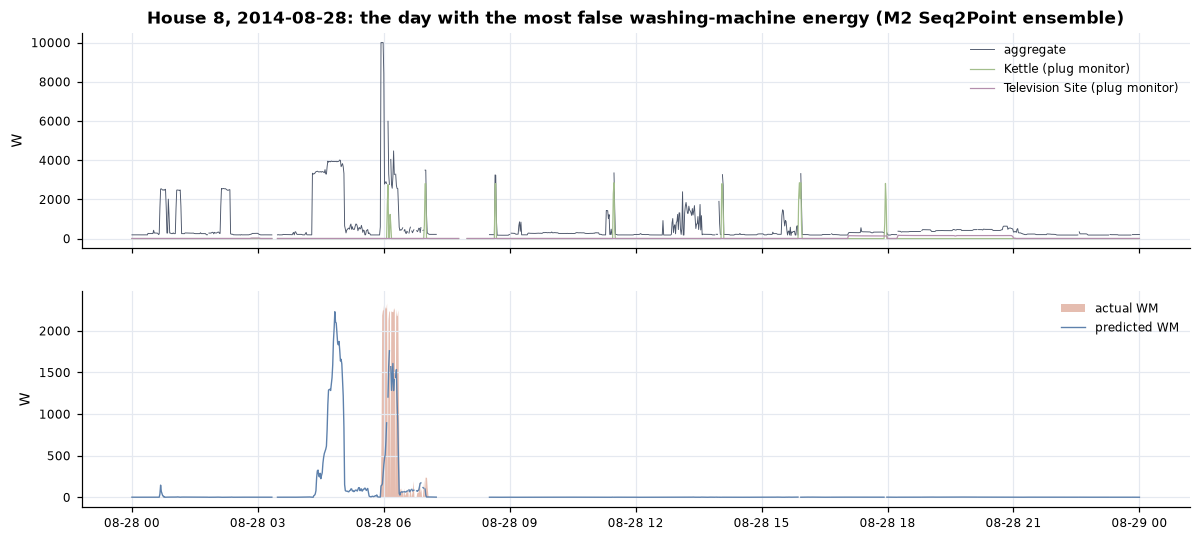

In [11]:
fpw = (p_pr - y8.fillna(0)).clip(lower=0)
worst = fpw.groupby(fpw.index.floor("D")).sum().idxmax()
sl3 = slice(worst, worst + pd.Timedelta("1D"))
fig, axes = plt.subplots(2, 1, figsize=(13, 5.6), sharex=True)
axes[0].plot(agg8[sl3].index, agg8[sl3], color=P["aggregate"], lw=0.6, label="aggregate")
top = raw8.loc[sl3, others].sum().sort_values(ascending=False).index[:2]
for c, col in zip(top, [P["alt"], P["alt2"]]):
    axes[0].plot(raw8.loc[sl3].index, raw8.loc[sl3, c], lw=0.8, color=col, label=f"{names8[c]} (plug monitor)")
axes[0].legend(loc="upper right")
axes[0].set_ylabel("W")
axes[0].set_title(f"House 8, {worst.date()}: the day with the most false washing-machine energy ({PRIMARY})")
axes[1].fill_between(y8[sl3].index, 0, y8[sl3].fillna(0), color=P["wm"], alpha=0.55, lw=0, label="actual WM")
axes[1].plot(p_pr[sl3].index, p_pr[sl3], color=P["pred"], lw=0.9, label="predicted WM")
axes[1].legend(loc="upper right")
axes[1].set_ylabel("W")
plots.save(fig, "nb06_worst_false_positive_day")
plt.show()

### 4b. Effect of the `Issues` flag (plug monitors summing above the aggregate)

Those minutes were excluded from training and scoring. Here the House 8 test set is rebuilt
with them included and scored with the primary model.

In [12]:
prefix = "M4 augmented" if PRIMARY.startswith("M4") else "M2 Seq2Point"
f8 = frames[h]
f8_all = f8.assign(target_ok=~f8["agg_missing"] & f8["wm"].notna())
cp_iss = D.build_corpus({h: f8_all}, {h: pd.Series("test", index=f8_all.index)}, W)
pi = predict_family(prefix, cp_iss)
s_i = cp_iss.starts["test"]
yi = D.to_series(cp_iss, s_i, cp_iss.wm[s_i + W // 2], h)
issue_tab = pd.DataFrame(
    [
        {"targets": "issues minutes excluded (standard)", "minutes": int(y8.notna().sum()), **{k: metrics.all_metrics(y8, p_pr, with_cycles=False)[k] for k in ["mae_w", "nde", "sae", "f1"]}},
        {"targets": "issues minutes included", "minutes": int(yi.notna().sum()), **{k: metrics.all_metrics(yi, D.to_series(cp_iss, s_i, pi, h), with_cycles=False)[k] for k in ["mae_w", "nde", "sae", "f1"]}},
    ]
).round(4)
issue_tab

,targets,minutes,mae_w,nde,sae,f1
0,issues minutes excluded (standard),691872,23.5735,0.7367,0.2837,0.4939
1,issues minutes included,704028,26.5200,0.7255,0.3374,0.5335


### 4c. House 1: official cleaned data vs my own cleaning of the raw files

This links Requirement 1 to Requirement 3. House 1 is an unseen home; here it is scored twice
with the same models, once on the official cleaned release and once on the series produced by
my raw-data pipeline in notebook 01. If my cleaning is sound, the scores should be close.

In [13]:
mine1 = pd.read_parquet(C.PARQUET_DIR / "raw_house1_clean_1min.parquet")
f1_mine = D.house_frame(1, "Appliance5", mine1)
cp_m = D.build_corpus({1: f1_mine}, {1: pd.Series("test", index=f1_mine.index)}, W)
h1_rows = []
for fam, pre in (("M2 Seq2Point ensemble", "M2 Seq2Point"), ("M4 augmented ensemble", "M4 augmented")):
    pm_ = predict_family(pre, cp_m)
    s_m = cp_m.starts["test"]
    ym = D.to_series(cp_m, s_m, cp_m.wm[s_m + W // 2], 1)
    r_mine = metrics.all_metrics(ym, D.to_series(cp_m, s_m, pm_, 1))
    r_off = scores[(scores.model == fam) & (scores.split == "test") & (scores.house == 1)].iloc[0]
    for label, r in (("official cleaned", r_off), ("my cleaning of raw", r_mine)):
        h1_rows.append({"model": fam, "data": label, **{k: float(r[k]) for k in ["mae_w", "nde", "sae", "epd_wh", "f1", "cycle_f1"]}})
h1_tab = pd.DataFrame(h1_rows).round(3)
h1_tab.to_csv(C.TABLE_DIR / "nb06_house1_official_vs_mine.csv", index=False)
h1_tab

,model,data,mae_w,nde,sae,epd_wh,f1,cycle_f1
0,M2 Seq2Point ensemble,official cleaned,7.609,0.859,0.261,93.962,0.321,0.174
1,M2 Seq2Point ensemble,my cleaning of raw,10.445,0.779,0.160,149.560,0.388,0.376
2,M4 augmented ensemble,official cleaned,8.675,0.801,0.621,100.997,0.329,0.234
3,M4 augmented ensemble,my cleaning of raw,11.282,0.726,0.050,143.414,0.401,0.464


## 5. What changes with 15- or 30-minute data?

Most utility smart meters report energy per 15 or 30 minutes (UK half-hourly settlement,
Indian AMI block-load profiles), not per minute. Two questions:

1. **Trained at the coarse resolution.** Both 1-minute series are averaged to 15 and 30
   minutes (an interval is usable only if ≥ 80 % of its minutes were usable), and Seq2Point is
   retrained with a ~4-hour window (17 and 9 samples): same homes, same validation house, seed
   42, batch 256 (there are 15–30× fewer samples).
2. **Fair comparison.** The 1-minute models' predictions are averaged to the same intervals and
   scored with the same metrics, so every row is evaluated at the same granularity.

One architecture (Seq2Point) is used so that the comparison isolates resolution. Cycle metrics
are not meaningful when a 60-minute cycle spans 2–4 samples, so the comparison uses MAE, NDE,
SAE, daily energy error (EpD) and interval-level F1.

In [14]:
res_rows, res_frames = [], {}
houses_r = C.TRAIN_HOUSES + [C.VAL_HOUSE] + UNSEEN
MKEYS = ["mae_w", "nde", "sae", "epd_wh", "f1", "precision", "recall"]
one_min = {"M2 Seq2Point s42 (1-min)": "M2 Seq2Point s42", f"{PRIMARY} (1-min)": PRIMARY}
for res in (15, 30):
    fr = {hh: D.resample_frame(frames[hh], res) for hh in houses_r}
    res_frames[res] = fr
    Wr = int(np.ceil(240 / res)) // 2 * 2 + 1
    cpr = D.build_corpus(fr, D.assign_splits(fr, D.SplitSpec(test_houses=UNSEEN), Wr), Wr)
    str_ = D.standardisation(cpr)
    cfg = T.TrainConfig(model="seq2point", window=Wr, seed=42, batch_size=256, max_epochs=60, patience=8)
    model, hist = T.fit(cpr, str_, cfg, device=DEVICE, log_every=100)
    out = T.predict(model, T.WindowSource(cpr, str_, DEVICE), cpr.starts["test"], str_)
    del model
    torch.cuda.empty_cache()
    st_r = cpr.starts["test"]
    for hh in UNSEEN:
        y = D.to_series(cpr, st_r, cpr.wm[st_r + Wr // 2], hh, freq=f"{res}min")
        yh = D.to_series(cpr, st_r, out["power"], hh, freq=f"{res}min")
        res_rows.append({"evaluated at": f"{res} min", "model": f"M2 Seq2Point s42 trained on {res}-min data", "house": hh, **{k: metrics.all_metrics(y, yh, with_cycles=False)[k] for k in MKEYS}})
        yc = fr[hh]["wm"].where(fr[hh]["target_ok"])
        for label, key in one_min.items():
            p1 = D.to_series(cp, cp.starts["test"], PRED[key]["test"]["power"], hh)
            pc = p1.resample(f"{res}min").mean().reindex(yc.index)
            res_rows.append({"evaluated at": f"{res} min", "model": f"{label}, averaged to {res} min", "house": hh, **{k: metrics.all_metrics(yc, pc, with_cycles=False)[k] for k in MKEYS}})
for label, key in one_min.items():
    for hh in UNSEEN:
        r = scores[(scores.model == key) & (scores.split == "test") & (scores.house == hh)].iloc[0]
        res_rows.append({"evaluated at": "1 min", "model": label, "house": hh, **{k: r[k] for k in MKEYS}})
res_tab = pd.DataFrame(res_rows)
res_tab.to_csv(C.TABLE_DIR / "nb06_resolution_all.csv", index=False)
res_sum = res_tab.groupby(["evaluated at", "model"])[MKEYS].mean().round(3)
res_h8 = res_tab[res_tab.house == C.TEST_HOUSE].set_index(["evaluated at", "model"])[MKEYS].round(3)
res_sum.to_csv(C.TABLE_DIR / "nb06_resolution_mean_unseen.csv")
res_h8.to_csv(C.TABLE_DIR / "nb06_resolution_house8.csv")
print("Mean over the six unseen homes:")
display(res_sum)
print("House 8:")
res_h8

Mean over the six unseen homes:


mae_w    nde    sae   epd_wh     f1  precision  recall
evaluated at model                                                                                                     
1 min        M2 Seq2Point ensemble (1-min)                      13.092  0.825  0.312  181.240  0.507      0.411   0.728
             M2 Seq2Point s42 (1-min)                           13.507  0.894  0.325  186.013  0.486      0.400   0.672
15 min       M2 Seq2Point ensemble (1-min), averaged to 15 min  11.719  0.921  0.477  173.261  0.508      0.403   0.746
             M2 Seq2Point s42 (1-min), averaged to 15 min       12.068  0.998  0.505  177.921  0.496      0.391   0.725
             M2 Seq2Point s42 trained on 15-min data            20.176  1.273  0.973  274.356  0.219      0.168   0.377
30 min       M2 Seq2Point ensemble (1-min), averaged to 30 min  11.424  0.874  0.455  176.430  0.517      0.411   0.741
             M2 Seq2Point s42 (1-min), averaged to 30 min       11.780  0.943  0.483  181.791  0.507      0.401   0.727
             M2 Seq2Point s42 trained on 30-min data            18.194  1.136  0.603  264.354  0.225      0.158   0.447

House 8:


mae_w    nde    sae   epd_wh     f1  precision  recall
evaluated at model                                                                                                     
15 min       M2 Seq2Point s42 trained on 15-min data            40.160  0.971  0.216  503.723  0.212      0.125   0.702
             M2 Seq2Point s42 (1-min), averaged to 15 min       21.018  0.739  0.252  318.080  0.469      0.324   0.849
             M2 Seq2Point ensemble (1-min), averaged to 15 min  20.844  0.732  0.245  312.737  0.477      0.326   0.887
30 min       M2 Seq2Point s42 trained on 30-min data            36.544  0.946  0.025  497.426  0.225      0.131   0.779
             M2 Seq2Point s42 (1-min), averaged to 30 min       20.970  0.740  0.269  335.879  0.491      0.346   0.844
             M2 Seq2Point ensemble (1-min), averaged to 30 min  20.719  0.733  0.262  326.830  0.499      0.348   0.877
1 min        M2 Seq2Point s42 (1-min)                           23.769  0.755  0.290  342.916  0.493      0.354   0.807
             M2 Seq2Point ensemble (1-min)                      23.573  0.737  0.284  334.805  0.494      0.343   0.881

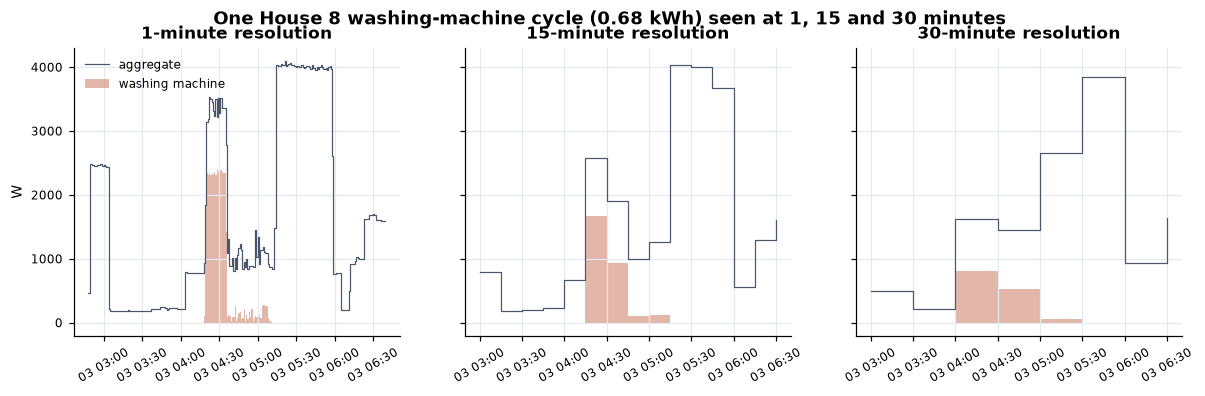

In [15]:
c = true_cyc.sort_values("energy_kwh").iloc[len(true_cyc) // 2]
sl4 = slice(c.start - pd.Timedelta("90min"), c.end + pd.Timedelta("90min"))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, res in zip(axes, (1, 15, 30)):
    src_f = frames[h] if res == 1 else res_frames[res][h]
    a, wv = src_f["agg"][sl4], src_f["wm"][sl4]
    ax.step(a.index, a, where="post", color=P["aggregate"], lw=0.8, label="aggregate")
    ax.fill_between(wv.index, 0, wv.fillna(0), step="post", color=P["wm"], alpha=0.6, lw=0, label="washing machine")
    ax.set_title(f"{res}-minute resolution")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("W")
axes[0].legend()
fig.suptitle(f"One House 8 washing-machine cycle ({c.energy_kwh:.2f} kWh) seen at 1, 15 and 30 minutes", fontweight="bold")
plots.save(fig, "nb06_cycle_at_three_resolutions")
plt.show()

## 6. Save

In [16]:
SUMMARY.update(
    {
        "house8_mean": h8_mean[KEY].round(4).to_dict(orient="index"),
        "house8_std": h8_std[KEY].round(4).to_dict(orient="index"),
        "unseen_mean": euh[KEY].round(4).to_dict(orient="index"),
        "seen_mean": seen_m[KEY].round(4).to_dict(orient="index"),
        "generalisation": gen.round(3).to_dict(orient="index"),
        "activation_filter_unseen": {" | ".join(k): v for k, v in filt.groupby(["model", "variant"])[["nde", "sae", "epd_wh", "f1", "precision", "cycle_f1", "overlap_pct", "extra_pct"]].mean().round(3).to_dict(orient="index").items()},
        "failure_taxonomy_house8": taxonomy.astype(str).to_dict(orient="index"),
        "issues_effect": issue_tab.to_dict(orient="records"),
        "house1_official_vs_mine": h1_tab.to_dict(orient="records"),
        "resolution_mean_unseen": {" | ".join(k): v for k, v in res_sum.to_dict(orient="index").items()},
        "resolution_house8": {" | ".join(k): v for k, v in res_h8.to_dict(orient="index").items()},
        "daily_energy_r_house8": daily_r,
        "plot_days": [str(d0.date()), str(d_end.date())],
        "worst_fp_day": str(worst.date()),
    }
)
with open(C.METRIC_DIR / "nb06_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)
print("saved")

saved


## Summary

**Primary model: the Seq2Point seed ensemble (M2), chosen on the validation house before this
notebook was run.** House 8 was scored once.

**House 8** (reference unseen test home; single deep models: mean of 3 seeds):

| model | NDE | SAE | EpD (Wh/day) | F1 | cycle F1 | cycle recall | true energy recovered | extra energy |
|---|---|---|---|---|---|---|---|---|
| always-off | 1.00 | 1.00 | 574 | 0 | 0 | 0 | 0 % | 0 % |
| weekday × hour profile | 1.00 | 0.35 | 536 | 0.05 | 0.03 | 0.08 | 2 % | 63 % |
| LightGBM | 1.01 | 0.50 | 531 | 0.05 | 0.02 | 0.02 | 2 % | 48 % |
| Seq2Point (single) | 0.77 ± 0.01 | 0.28 | 340 | 0.51 | 0.56 ± 0.04 | 0.64 | 37 % | 34 % |
| gated Seq2Point | 0.77 ± 0.03 | 0.23 | 347 | 0.45 | 0.37 | 0.44 | 41 % | 46 % |
| augmented Seq2Point | 0.69 ± 0.02 | 0.18 | 309 | 0.45 | 0.53 | 0.82 | 49 % | 53 % |
| **Seq2Point ensemble (primary)** | **0.74** | **0.28** | **335** | **0.49** | **0.56** | **0.75** | **38 %** | **34 %** |
| augmented ensemble | 0.66 | 0.02 | 292 | 0.43 | 0.47 | 0.85 | 49 % | 53 % |

**All six unseen homes (mean).** Primary model: NDE 0.83 (always-off 1.00), daily energy error
181 Wh/day (always-off 308), total-energy error SAE 0.31, minute F1 0.51, cycle F1 0.48. Skill
varies widely by home: NDE 0.42 in House 6, 0.71–0.86 in Houses 1, 8, 10 and 20, and 1.40 in
House 19, which mostly runs low-power, unheated washes that the model over-predicts.

**Seen vs unseen.** NDE rises from 0.57 on later data of the training homes to 0.83 on new homes
(generalisation loss 45 %); F1 falls from 0.61 to 0.51. Most of the error is about *new homes*,
not about time.

**What the models get right and wrong (House 8, primary model).**
* It finds **75 % of real cycles** (232 of 310). The 78 it misses are smaller (median 0.46 kWh vs
  0.76 kWh for the cycles it finds).
* It produces **281 false cycles**; at those times the largest metered appliance is usually
  nothing at all (193, i.e. unmetered load such as showers or cooking), then the kettle (32),
  washer-dryer (19) and microwave (19).
* Within the cycles it finds, it **under-predicts energy by 59 %**: the heating block is found,
  the long low-power tail is largely missed. The days plot shows exactly this.
* Daily energy: r = 0.74 between predicted and actual kWh per day.

**Post-processing.** The activation filter cuts false energy from 59 % to 17 % of true energy and
raises minute precision from 0.41 to 0.54, at the cost of recovered energy (42 % → 28 %). It suits
cycle counting, not energy reporting.

**The augmented model**, rejected on validation, is better than the primary model on House 8
(NDE 0.66, total energy almost exact) but worse on the six-home mean (NDE 0.91 vs 0.83) and
predicts twice the false energy. The validation decision holds up on the broader test set.

**A label-quality problem found here (most important lesson).** On House 1, scoring against my own
cleaning of the raw files gives cycle F1 0.38, against 0.17 on the official release. The two
series agree minute by minute (≤ 39 minutes differ in on/off state); the difference is the
`Issues` flag. In the official release it fires whenever any 8-second row in a minute has the plug
monitors summing above the aggregate, which happens precisely when a large appliance switches. It
therefore removes washing minutes far more often than other minutes: in the training and validation
homes it covers 1–8 % of all minutes but **5–47 % of washing-machine-on minutes**, and **5–50 % of
washing-machine energy** (`artifacts/tables/issues_flag_vs_wm_on_trainval.csv`). Excluding those
minutes, as the README suggests, fragments true cycles and thins the positive labels. For House 8,
whose flag rate is low, including them changes little (NDE 0.737 → 0.726). The first change for a
next version is to keep these minutes and use the flag as a weight or feature, re-validated from
scratch.

**15- and 30-minute data.** Averaging a 1-minute model's output to 15 or 30 minutes keeps its skill
(six-home NDE 0.87–0.92, daily error ~175 Wh/day). A model that only *sees* 15- or 30-minute data
loses it: NDE 1.14–1.27 (worse than predicting zero), daily error ~270 Wh/day, interval F1 0.22.
On House 8 the coarse-input models' daily error (~500 Wh/day) is close to always-off (574). At
these resolutions a 2 kW, 15-minute heating block becomes one or two averaged values
indistinguishable from other loads (figure above). Per-interval disaggregation of washing machines
from 15/30-minute smart-meter data is not viable with this approach; usage-day detection and
monthly energy estimates are the realistic products at that resolution.

## Verification log

* House 8 was not used for any choice. An earlier run of this notebook was stopped when I decided
  to add the augmented model; its partial outputs were deleted without being opened.
* The primary model was fixed in notebook 05b (`nb05b_summary.json`, `accepted: false` → M2
  ensemble) before this notebook ran.
* Spot checks: the three-day House 8 plot shows the ensemble catching the heating blocks and
  missing the low-power tails, consistent with the −59 % matched-energy bias; the resolution figure
  shows the heating block smeared into averaged values.
* The House 1 discrepancy was traced to the `Issues` flag by comparing the two label series minute
  by minute before attributing it.